# 01 — Turkish MASSIVE: data exploration

Intent classification for Turkish voice-assistant commands, using the **tr-TR** portion of
[Amazon MASSIVE](https://github.com/alexa/massive) (FitzGerald et al., 2022).

This notebook establishes the ground facts every later experiment is measured against:
split sizes, the intent inventory and its imbalance, utterance characteristics, and the
Turkish-specific properties that make this task harder than its English equivalent.

Everything here is computed from the dataset — no numbers are carried over from the paper.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alper4n/turkish-intent-llm/blob/main/notebooks/01_data_exploration.ipynb)

## 0. Setup

In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/alper4n/turkish-intent-llm.git"
    if not Path("turkish-intent-llm").exists():
        !git clone -q $REPO_URL
    %cd turkish-intent-llm
    # pandas / numpy / matplotlib / pyyaml ship with Colab; this notebook needs nothing else.

# Make `src` importable whether we are at the repo root or inside notebooks/.
root = Path.cwd()
while not (root / "src").is_dir() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
print("repo root:", root)

repo root: /Users/Alperen MacBook/turkish-intent-llm


In [2]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

from src.data import load_locale, load_splits, intent_labels
from src.utils import load_config, save_results, set_seed

cfg = load_config(root / "configs" / "data.yaml")
set_seed(cfg["seed"])

FIG_DIR = root / cfg["paths"]["figures_dir"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 60)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})

cfg["dataset"]

{'name': 'amazon-massive',
 'version': '1.0',
 'locale': 'tr-TR',
 'url': 'https://amazon-massive-nlu-dataset.s3.amazonaws.com/amazon-massive-dataset-1.0.tar.gz',
 'sha256': '7df623fd2d300a4d235d6ee5bd396c9a28258d3a0ccb29abdb054506eba153f8',
 'cache_dir': 'data/raw',
 'text_field': 'utt',
 'label_field': 'intent'}

## 1. Load the data

`src.data` downloads the official Amazon tarball, verifies its SHA-256 and extracts the
single locale we need. We deliberately do **not** use the Hugging Face
`AmazonScience/massive` repository: it is a script-based dataset, and `datasets>=3.0`
refuses to run dataset scripts, so that path breaks on a current Colab runtime.

In [3]:
splits = load_splits(cfg["dataset"]["locale"], cache_dir=root / cfg["dataset"]["cache_dir"])
full = pd.concat(splits.values(), ignore_index=True)
LABELS = intent_labels(full)

print(f"locale   : {cfg['dataset']['locale']}")
print(f"rows     : {len(full):,}")
print(f"intents  : {len(LABELS)}")
print(f"scenarios: {full['scenario'].nunique()}")
full.head()

locale   : tr-TR
rows     : 16,521
intents  : 60
scenarios: 18


,id,split,scenario,intent,utt,annot_utt,worker_id,n_judgments,intent_score,grammar_score,spelling_score
0,1,train,alarm,alarm_set,beni cuma günü sabah dokuzda uyandır,beni [date : cuma] günü [time : sabah dokuzda] uyandır,12,3,1.0,4.000000,2.0
1,2,train,alarm,alarm_set,iki saat sonrasına alarm kur,[time : iki saat sonrasına] alarm kur,12,3,1.0,4.000000,2.0
2,4,train,audio,audio_volume_mute,olly sessiz ol,olly sessiz ol,8,3,1.0,3.666667,2.0
3,5,train,audio,audio_volume_mute,dur,dur,3,3,1.0,4.000000,2.0
4,6,train,audio,audio_volume_mute,olly on saniye duraklat,olly [time : on saniye] duraklat,8,3,1.0,3.666667,2.0


## 2. Split sizes

In [4]:
split_table = pd.DataFrame({
    "utterances": {name: len(part) for name, part in splits.items()},
    "intents": {name: part["intent"].nunique() for name, part in splits.items()},
    "scenarios": {name: part["scenario"].nunique() for name, part in splits.items()},
})
split_table["share"] = (split_table["utterances"] / split_table["utterances"].sum()).round(3)
split_table

,utterances,intents,scenarios,share
train,11514,60,18,0.697
validation,2033,59,18,0.123
test,2974,59,18,0.180


These are MASSIVE's **published** partitions, used exactly as distributed. No re-splitting,
so results stay comparable with any other work on this dataset.

## 3. Intent distribution

Macro-F1 is the headline metric for this project, so the size of the smallest classes
matters more than the average. Let us see how skewed the label distribution actually is.

In [5]:
train_counts = splits["train"]["intent"].value_counts()

imbalance = {
    "n_intents": int(train_counts.size),
    "max_count": int(train_counts.max()),
    "min_count": int(train_counts.min()),
    "median_count": float(train_counts.median()),
    "imbalance_ratio": round(float(train_counts.max() / train_counts.min()), 2),
    "intents_under_100_train": int((train_counts < 100).sum()),
    "intents_under_50_train": int((train_counts < 50).sum()),
}
for key, value in imbalance.items():
    print(f"{key:<24} {value}")

n_intents                60
max_count                810
min_count                4
median_count             128.5
imbalance_ratio          202.5
intents_under_100_train  18
intents_under_50_train   6


In [6]:
print("10 most frequent intents (train)")
print(train_counts.head(10).to_string())
print()
print("10 rarest intents (train)")
print(train_counts.tail(10).to_string())

10 most frequent intents (train)
intent
calendar_set       810
play_music         639
weather_query      573
calendar_query     566
general_quirky     555
qa_factoid         544
news_query         503
email_query        418
email_sendemail    354
datetime_query     350

10 rarest intents (train)
intent
iot_wemo_off          52
datetime_convert      52
audio_volume_down     52
music_settings        51
iot_wemo_on           48
general_greet         25
iot_hue_lighton       22
audio_volume_other    18
music_dislikeness     14
cooking_query          4


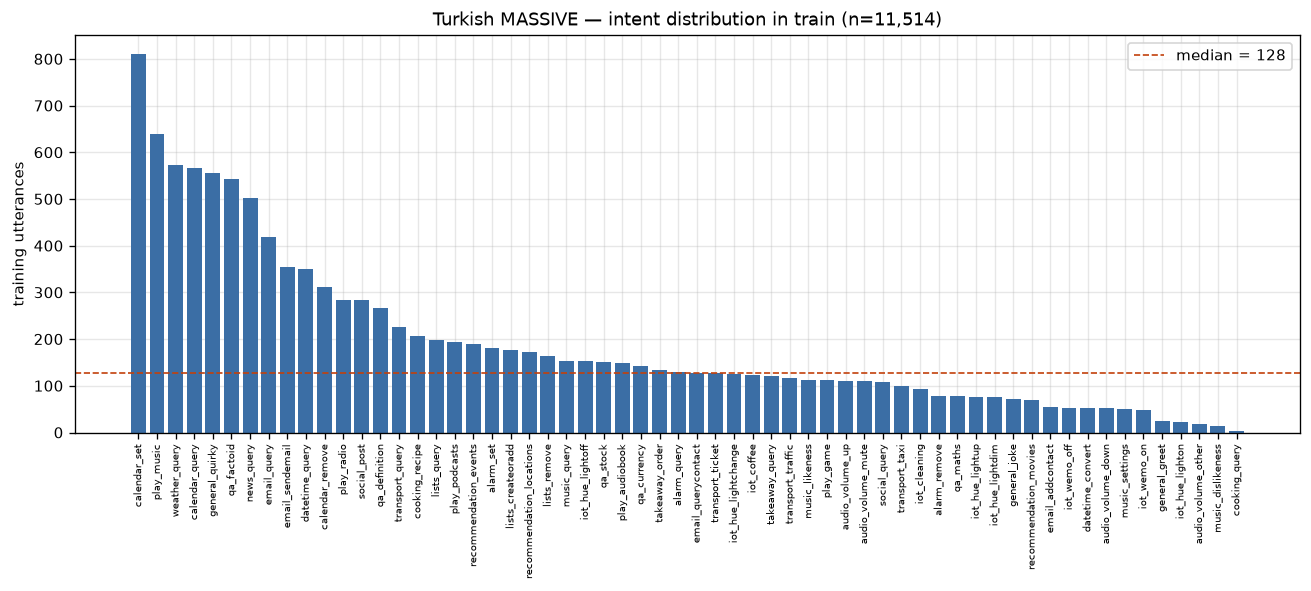

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
ordered = train_counts.sort_values(ascending=False)
ax.bar(range(len(ordered)), ordered.values, color="#3b6ea5", width=0.8)
ax.set_xticks(range(len(ordered)))
ax.set_xticklabels(ordered.index, rotation=90, fontsize=6)
ax.set_ylabel("training utterances")
ax.set_title(f"Turkish MASSIVE — intent distribution in train (n={len(splits['train']):,})")
ax.axhline(ordered.median(), color="#c2410c", ls="--", lw=1,
           label=f"median = {ordered.median():.0f}")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "intent_distribution.png", bbox_inches="tight")
plt.show()

## 4. Scenario distribution

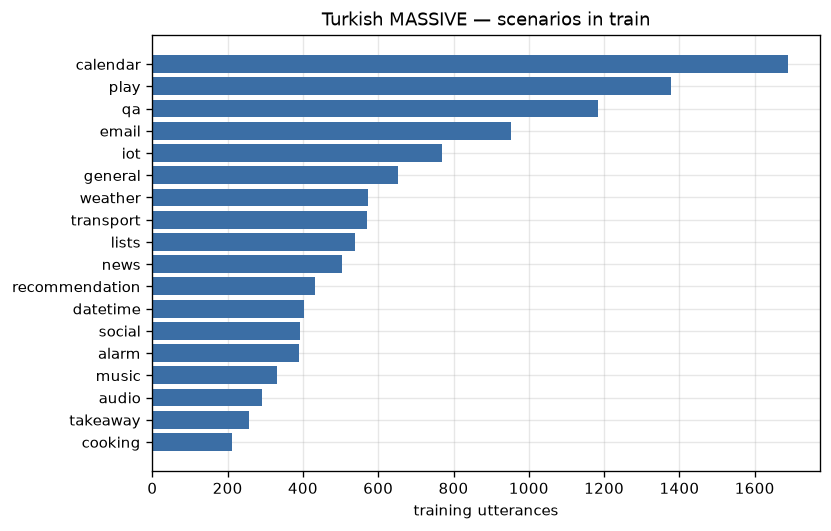

,train_utterances
scenario,
calendar,1688
play,1377
qa,1183
email,953
iot,769
general,652
weather,573
transport,571
lists,539


In [8]:
scenario_counts = splits["train"]["scenario"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(scenario_counts.index[::-1], scenario_counts.values[::-1], color="#3b6ea5")
ax.set_xlabel("training utterances")
ax.set_title("Turkish MASSIVE — scenarios in train")
fig.tight_layout()
fig.savefig(FIG_DIR / "scenario_distribution.png", bbox_inches="tight")
plt.show()

scenario_counts.to_frame("train_utterances")

## 5. Example utterances

In [9]:
rng_intents = sorted(pd.Series(LABELS).sample(8, random_state=cfg["seed"]).tolist())
for intent in rng_intents:
    print(f"--- {intent} ---")
    subset = splits["train"][splits["train"]["intent"] == intent]
    for utt in subset["utt"].head(3):
        print("   ", utt)

--- alarm_query ---
    lütfen aktif alarmları listele
    kurduğum alarmları göster
    herhangi alarmım var mı
--- audio_volume_other ---
    ses seviyesini değiştir
    hoparlörlerin sesini değiştir
    ses ayarlarını değiştir
--- datetime_query ---
    bana moskova'da saatin kaç olduğunu söyle
    saat kaç
    bana saati söyle
--- music_dislikeness ---
    hoşuma gitmedi
    bu fondaki şarkı sıkıcı
    bu şarkı pek iyi değil
--- music_settings ---
    bu oynatma listesini karıştır
    karışık çalmayı etkinleştir
    ayarları kaydet
--- qa_factoid ---
    birleşik devletlerin gayri safi yurtiçi hasılası nedir
    bana alparslan türkeş hakkında bilgi ver
    kim cumali koçak santimetre yardımcısı olarak atandı
--- recommendation_events ---
    neler oluyor olly
    neler oluyor
    şu anki yerel etkinlikler
--- takeaway_query ---
    olly çin yemeği için en yüksek yıldızlı teslimat opsiyonlarını listele
    çin yemeği için en yüksek yıldızlı adrese teslimat opsiyonlar
    olly çin ye

## 6. Utterance length

Voice-assistant commands are short, which limits how much context any classifier gets.

In [10]:
for part in splits.values():
    part["n_chars"] = part["utt"].str.len()
    part["n_words"] = part["utt"].str.split().str.len()
full = pd.concat(splits.values(), ignore_index=True)

length_stats = full.groupby("split", observed=True)[["n_chars", "n_words"]].describe().round(2)
length_stats.loc[:, [("n_words", "mean"), ("n_words", "50%"), ("n_words", "max"),
                     ("n_chars", "mean"), ("n_chars", "max")]]

n_words            n_chars       
              mean  50%   max    mean    max
split                                       
train         5.49  5.0  24.0   35.03  206.0
validation    5.43  5.0  23.0   34.61  150.0
test          5.45  5.0  50.0   34.81  366.0

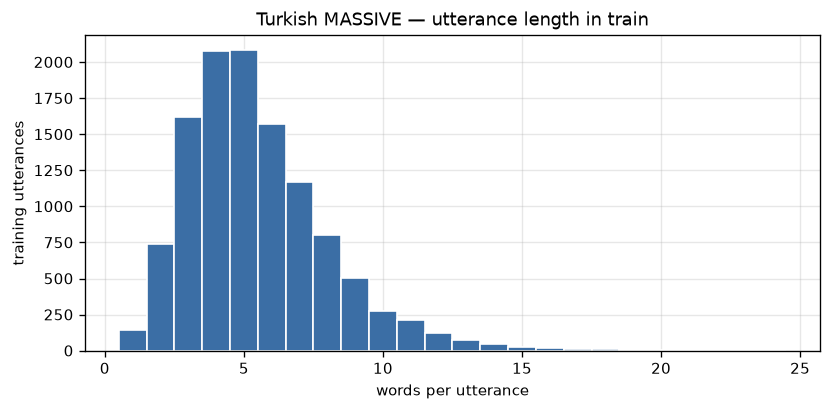

21.7% of training utterances are 3 words or shorter


In [11]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(splits["train"]["n_words"], bins=range(1, 26), color="#3b6ea5",
        edgecolor="white", align="left")
ax.set_xlabel("words per utterance")
ax.set_ylabel("training utterances")
ax.set_title("Turkish MASSIVE — utterance length in train")
fig.tight_layout()
fig.savefig(FIG_DIR / "utterance_length.png", bbox_inches="tight")
plt.show()

short = (splits["train"]["n_words"] <= 3).mean()
print(f"{short:.1%} of training utterances are 3 words or shorter")

## 7. Turkish-specific properties

MASSIVE is a **parallel** corpus: every utterance id carries the same intent and the same
split across all 51 locales. That lets us hold meaning constant and measure what changes
when the language changes — the cleanest available evidence for how Turkish agglutination
reshapes the input a classifier sees.

In [12]:
english = load_locale("en-US", cache_dir=root / cfg["dataset"]["cache_dir"])
parallel = (
    full[["id", "split", "intent", "utt", "n_words", "n_chars"]]
    .merge(english[["id", "utt"]], on="id", suffixes=("_tr", "_en"))
)
parallel["n_words_en"] = parallel["utt_en"].str.split().str.len()
parallel["n_chars_en"] = parallel["utt_en"].str.len()

comparison = pd.DataFrame({
    "Turkish": [parallel["n_words"].mean(), parallel["n_chars"].mean(),
                parallel["n_chars"].sum() / parallel["n_words"].sum()],
    "English": [parallel["n_words_en"].mean(), parallel["n_chars_en"].mean(),
                parallel["n_chars_en"].sum() / parallel["n_words_en"].sum()],
}, index=["mean words / utterance", "mean chars / utterance", "mean chars / word"]).round(2)
comparison["Turkish / English"] = (comparison["Turkish"] / comparison["English"]).round(3)
comparison

,Turkish,English,Turkish / English
mean words / utterance,5.48,6.90,0.794
mean chars / utterance,34.94,34.92,1.001
mean chars / word,6.38,5.06,1.261


Turkish packs the same meaning into fewer, longer words: grammatical information that
English spreads over separate function words is suffixed onto the stem. A word-level
feature space therefore fragments far more in Turkish, which is exactly why the classical
baseline in this project is a **subword** model (BERTurk) rather than bag-of-words.

In [13]:
# Side-by-side examples of the same command in both languages.
for _, row in parallel.sample(6, random_state=cfg["seed"]).iterrows():
    print(f"[{row['intent']}]")
    print(f"   TR ({row['n_words']:>2}w): {row['utt_tr']}")
    print(f"   EN ({row['n_words_en']:>2}w): {row['utt_en']}")

[transport_query]
   TR ( 3w): bursa'ya sürüş zamanı
   EN ( 5w): driving time to los angeles
[play_game]
   TR ( 2w): satranç aç
   EN ( 2w): play chess
[play_radio]
   TR ( 4w): radyo bandını belgeselle aç
   EN ( 6w): play the radio band with documentary
[calendar_set]
   TR ( 4w): bu etkinliği takvimime ekle
   EN ( 6w): include this event in my calendar
[calendar_set]
   TR ( 3w): bana toplantıyı hatırlat
   EN ( 4w): remind me about meeting
[qa_currency]
   TR ( 5w): dolar ı tl kuruna çevir
   EN ( 5w): change dollar to rupees rates


### 7.1 Orthography: Turkish-specific characters

`ç ğ ı ö ş ü` are routinely dropped in typed Turkish, and ASR output is not always
consistent either. Any model has to survive that variation, so we first measure how much
of it the corpus contains.

In [14]:
TR_CHARS = set("çğıöşüÇĞIİÖŞÜ")
ASCII_FOLD = str.maketrans("çğıöşüÇĞİÖŞÜ", "cgiosuCGIOSU")

full["has_tr_chars"] = full["utt"].apply(lambda s: any(ch in TR_CHARS for ch in s))
full["ascii_folded"] = full["utt"].str.translate(ASCII_FOLD)

orthography = {
    "utterances_with_turkish_chars": float(full["has_tr_chars"].mean()),
    "ascii_folding_collisions": int(
        full.loc[full["has_tr_chars"], "ascii_folded"].isin(set(full["utt"])).sum()
    ),
}
print(f"{orthography['utterances_with_turkish_chars']:.1%} of utterances contain at least "
      f"one of ç ğ ı ö ş ü")
print(f"{orthography['ascii_folding_collisions']} utterances collide with an existing "
      f"utterance once diacritics are stripped")

90.0% of utterances contain at least one of ç ğ ı ö ş ü
0 utterances collide with an existing utterance once diacritics are stripped


The corpus turns out to be orthographically **clean**: diacritics are used consistently and
stripping them never produces a string that already exists elsewhere in the data. That is a
finding about MASSIVE, not about Turkish — these utterances were produced by paid
translators, not typed into a phone.

The practical consequence is a gap rather than a nuisance: a model trained on this data
never sees `yarin sabah alarm kur` for `yarın sabah alarm kur`, even though diacritic-free
input is ordinary in real typed Turkish. We therefore treat ASCII-folding robustness as an
explicit probe in the error-analysis notebook instead of assuming the test set measures it.

### 7.2 Annotation quality signals

MASSIVE ships per-annotator judgments, which we average per utterance. The scales are
`intent_score` 0–2, `grammar_score` 0–4 and `spelling_score` 0–2, with higher being better.
They give us an independent, human-assigned handle on how noisy an utterance is — useful
later when we ask whether model errors concentrate on degraded input.

In [15]:
quality = full[["intent_score", "grammar_score", "spelling_score"]].describe().round(3)
print(quality.loc[["mean", "min", "25%", "50%", "max"]].to_string())

worst = full.nsmallest(8, "spelling_score")[["intent", "spelling_score", "utt"]]
print("\nLowest spelling-score utterances:")
print(worst.to_string(index=False))

      intent_score  grammar_score  spelling_score
mean         1.004          3.871           1.947
min          0.000          0.333           0.000
25%          1.000          4.000           2.000
50%          1.000          4.000           2.000
max          1.667          4.000           2.000

Lowest spelling-score utterances:
         intent  spelling_score                                                                                 utt
   lists_remove        0.000000                          bu beni çok çok horkersd wo içinde iyi şanslı adam yapıyor
   calendar_set        0.666667                                    benim yoga pratiğim için her gün öğle vaktimde u
 play_audiobook        0.666667                          kitaplar ı aç ve dokuz uncu bölüm de beyin kitabı nı oynat
email_sendemail        0.666667                        anneme e-posta gönder ve onu disney world'de gördüğünü söyle
email_sendemail        0.666667 lütfen ahmetin yeni eposta adresine bir eposta gönder

### 7.3 Ambiguous utterances

Identical surface forms mapped to more than one intent set a hard ceiling on accuracy: no
model can separate them from the text alone. These pairs are the first place to look in the
error analysis.

In [16]:
dupes = (
    full.groupby("utt")["intent"].nunique().loc[lambda s: s > 1].index
)
ambiguous = full[full["utt"].isin(dupes)]

confusable_pairs = Counter()
for utt, group in ambiguous.groupby("utt"):
    intents = sorted(group["intent"].unique())
    for i in range(len(intents)):
        for j in range(i + 1, len(intents)):
            confusable_pairs[(intents[i], intents[j])] += 1

print(f"{len(dupes)} distinct utterances carry more than one intent label")
print(f"({len(ambiguous)} rows, {len(ambiguous) / len(full):.2%} of the corpus)\n")
print("Most frequent intrinsically confusable intent pairs:")
for (a, b), n in confusable_pairs.most_common(10):
    print(f"  {n:>3}  {a}  <->  {b}")

36 distinct utterances carry more than one intent label
(106 rows, 0.64% of the corpus)

Most frequent intrinsically confusable intent pairs:
    3  general_greet  <->  general_quirky
    2  calendar_remove  <->  lists_remove
    2  audio_volume_down  <->  audio_volume_mute
    2  iot_hue_lightdim  <->  iot_hue_lightoff
    2  play_audiobook  <->  play_music
    2  calendar_query  <->  recommendation_events
    2  iot_hue_lighton  <->  iot_hue_lightup
    1  alarm_set  <->  calendar_set
    1  general_quirky  <->  qa_definition
    1  general_quirky  <->  lists_query


In [17]:
print("Examples of the same utterance under different intents:")
for utt in list(dupes)[:6]:
    labels = sorted(full.loc[full["utt"] == utt, "intent"].unique())
    print(f"  {utt!r}")
    print(f"      -> {', '.join(labels)}")

Examples of the same utterance under different intents:
  'alarm'
      -> alarm_set, calendar_set
  'açıkla'
      -> general_quirky, qa_definition
  'bugün nasılsın'
      -> general_greet, general_quirky
  'bugün ne yapmam gerekiyor'
      -> general_quirky, lists_query
  'bugün neler oluyor'
      -> general_quirky, news_query
  'döviz kurları'
      -> qa_currency, qa_stock


## 8. Consistency checks

Before modelling, two things must hold: the splits must not overlap, and we need to know
exactly which intents each split actually contains. The second one turns out to matter.

In [18]:
missing = {name: sorted(set(LABELS) - set(part["intent"].unique()))
           for name, part in splits.items()}
overlap = len(set(splits["train"]["id"]) & set(splits["test"]["id"]))

print("train/test id overlap :", overlap)
print("duplicate ids overall :", int(full["id"].duplicated().sum()))
print("intents per split     :",
      {name: int(part["intent"].nunique()) for name, part in splits.items()})
print()
for name, labels in missing.items():
    if labels:
        print(f"absent from {name}: {labels}")

affected = sorted({label for labels in missing.values() for label in labels})
if affected:
    print()
    print(pd.crosstab(full.loc[full["intent"].isin(affected), "intent"],
                      full.loc[full["intent"].isin(affected), "split"]).to_string())

train/test id overlap : 0
duplicate ids overall : 0
intents per split     : {'train': 60, 'validation': 59, 'test': 59}

absent from validation: ['audio_volume_other']
absent from test: ['cooking_query']

split               train  validation  test
intent                                     
audio_volume_other     18           0     6
cooking_query           4           2     0


**This changes how macro-F1 must be computed.** `cooking_query` has 4 training utterances
and *no test utterances at all*; `audio_volume_other` is absent from validation. If we hand
scikit-learn all 60 labels, it scores the absent class as 0.0 and silently drags macro-F1
down by roughly `1/60` — a penalty that reflects the dataset, not the model.

So the rule for every experiment in this repo: **the label space stays at all 60 intents**
(the models may still predict `cooking_query`), but **macro-F1 is averaged only over the
intents actually present in the evaluation split**, and the excluded label is recorded in
the results JSON. Both conventions are reported so the numbers can be compared with papers
that chose the other one.

## 9. Save the summary

Everything the README quotes about the data is written here, so the two can never drift
apart.

In [19]:
summary = {
    "dataset": {
        "name": cfg["dataset"]["name"],
        "version": cfg["dataset"]["version"],
        "locale": cfg["dataset"]["locale"],
        "source_url": cfg["dataset"]["url"],
        "sha256": cfg["dataset"]["sha256"],
    },
    "splits": {name: int(len(part)) for name, part in splits.items()},
    "n_intents": len(LABELS),
    "n_scenarios": int(full["scenario"].nunique()),
    "label_coverage": {
        "intents_per_split": {
            name: int(part["intent"].nunique()) for name, part in splits.items()
        },
        # Consumed by src/metrics.py: macro-F1 is averaged over present labels only.
        "absent_intents": {name: labels for name, labels in missing.items()},
    },
    "intent_imbalance": imbalance,
    "utterance_length": {
        "mean_words": round(float(full["n_words"].mean()), 2),
        "median_words": float(full["n_words"].median()),
        "max_words": int(full["n_words"].max()),
        "mean_chars": round(float(full["n_chars"].mean()), 2),
        "share_under_4_words": round(float((full["n_words"] <= 3).mean()), 4),
    },
    "parallel_tr_vs_en": {
        "mean_words_tr": round(float(parallel["n_words"].mean()), 2),
        "mean_words_en": round(float(parallel["n_words_en"].mean()), 2),
        "mean_chars_per_word_tr": round(
            float(parallel["n_chars"].sum() / parallel["n_words"].sum()), 2),
        "mean_chars_per_word_en": round(
            float(parallel["n_chars_en"].sum() / parallel["n_words_en"].sum()), 2),
    },
    "orthography": {
        "share_with_turkish_chars": round(
            orthography["utterances_with_turkish_chars"], 4),
        "ascii_folding_collisions": orthography["ascii_folding_collisions"],
    },
    "ambiguity": {
        "utterances_with_multiple_intents": int(len(dupes)),
        "rows_affected": int(len(ambiguous)),
        "share_of_corpus": round(float(len(ambiguous) / len(full)), 4),
        "top_confusable_pairs": [
            {"intents": [a, b], "count": int(n)}
            for (a, b), n in confusable_pairs.most_common(10)
        ],
    },
    "intent_labels": LABELS,
}

path = save_results(summary, "data_summary", results_dir=root / cfg["paths"]["results_dir"])
print("wrote", path)

wrote /Users/Alperen MacBook/turkish-intent-llm/results/data_summary.json


## Takeaways for the experiments

1. **60 intents over 11.5k training utterances** — a small-data regime where a pretrained
   encoder should be competitive and a from-scratch model would not be.
2. **The label distribution is severely skewed**: the largest intent has 810 training
   utterances, the smallest has 4. Accuracy alone would flatter a model that ignores the
   tail, so macro-F1 is reported alongside it everywhere.
3. **`cooking_query` never appears in test**, so macro-F1 is averaged over the 59 intents
   present in the evaluation split, with the convention recorded in every results file.
4. **Utterances are short** (5.5 words on average, 22% at three words or fewer) and Turkish
   packs ~26% more characters into each word than parallel English. Morphology carries much
   of the signal, which is why the classical baseline is a subword model.
5. **0.64% of rows are intrinsically ambiguous** — the same string under different intents.
   That is a ceiling on achievable accuracy and the first thing to check in a confusion
   matrix; the confusable pairs found here are the ones to look for.
6. **Diacritics are used consistently**, so robustness to ASCII-folded Turkish has to be
   probed deliberately rather than read off the test score.

Next: `02_baseline_berturk.ipynb` — fine-tune `dbmdz/bert-base-turkish-cased` as the
classical baseline.